# Importing Libraries

In [5]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

from src.config import *

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import joblib
import shap

import warnings
warnings.filterwarnings("ignore")

# Loading Final Pipeline

In [2]:
final_pipeline = joblib.load(
    MODEL_DIR / "validated_final_model.pkl"
)

label_encoder = joblib.load(
    ARTIFACT_DIR / "cv_label_encoder.pkl"
)

# Loading the dataset so 'X' is explicitly defined

In [7]:
df = pd.read_parquet(PROCESSED_DATA_DIR / "breast_cancer.parquet")

TARGET_COL = "type"
X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL]

# Extract the fitted steps from our pipeline

In [8]:
feature_selector = final_pipeline.named_steps["feature_selection"]
scaler = final_pipeline.named_steps["scaler"]
rf_model = final_pipeline.named_steps["model"]
print("Pipeline steps and data matrices successfully initialized!")

Pipeline steps and data matrices successfully initialized!


# Extracting Selected Genes and Transform the Data

In [9]:
X_selected = feature_selector.transform(X)

X_scaled = scaler.transform(X_selected)

# Recovering the actual gene names for the 1,000 selected features

In [10]:
selected_mask = feature_selector.get_support()
selected_gene_names = X.columns[selected_mask]

print(f"Preprocessed shape for SHAP: {X_scaled.shape}")
print(f"Number of retrieved gene names: {len(selected_gene_names)}")

Preprocessed shape for SHAP: (151, 1000)
Number of retrieved gene names: 1000


# Compute Tree SHAP Values

In [11]:
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_scaled)

print(f"Type of shap_values: {type(shap_values)}")
print(f"SHAP array shape: {np.array(shap_values).shape}")

Type of shap_values: <class 'numpy.ndarray'>
SHAP array shape: (151, 1000, 6)


# Plotting Global Biomarker Importance

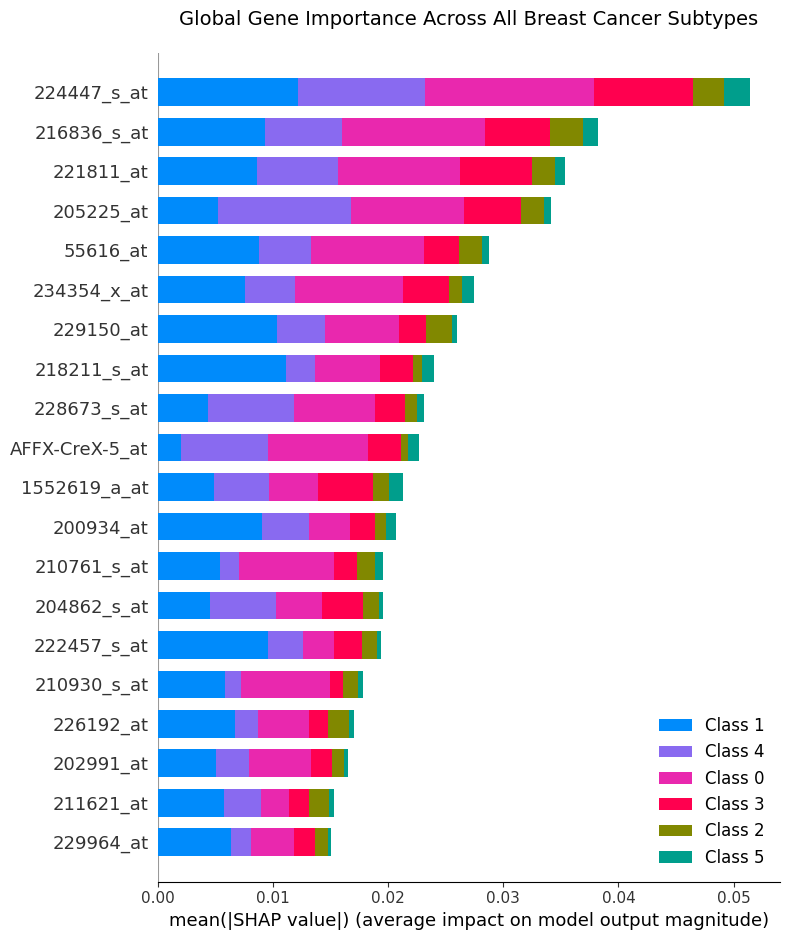

In [12]:
plt.figure(figsize=(12, 8))
shap.summary_plot(
    shap_values,
    X_scaled,
    feature_names=selected_gene_names,
    plot_type="bar",
    show=False
)
plt.title("Global Gene Importance Across All Breast Cancer Subtypes", fontsize=14, pad=20)
plt.tight_layout()
plt.savefig(ARTIFACT_DIR / "global_shap_importance.png", dpi=300)
plt.show()

# Saving Global Importance DataFrame

In [15]:
mean_shap = np.abs(np.array(shap_values)).mean(axis=(0, 2))

shap_importance = pd.DataFrame({
    "gene": selected_gene_names,
    "importance": mean_shap
}).sort_values(by="importance", ascending=False)

shap_importance.to_parquet(ARTIFACT_DIR / "shap_importance.parquet", index=False)
print("Top 10 Globally Important Biomarkers:")
print(shap_importance.head(10))

Top 10 Globally Important Biomarkers:
               gene  importance
606     224447_s_at    0.008577
436     216836_s_at    0.006373
537       221811_at    0.005887
206       205225_at    0.005688
978        55616_at    0.004794
767     234354_x_at    0.004581
677       229150_at    0.004322
463     218211_s_at    0.003991
668     228673_s_at    0.003856
983  AFFX-CreX-5_at    0.003774


# Subtype-Specific Biomarkers (Fixing the Basal Example)

In [20]:
# 1. Identify the class index for the basal subtype (lowercase)
try:
    target_subtype = "basal"
    basal_class_idx = list(label_encoder.classes_).index(target_subtype)
    print(f"Class '{target_subtype}' successfully found at index: {basal_class_idx}")
    
    # 2. Slice the 3rd axis for basal, then take the absolute mean over all samples (axis 0)
    # shap_array shape is (151, 1000, 6) -> slicing [:, :, 1] leaves (151, 1000)
    basal_importance = np.abs(shap_array[:, :, basal_class_idx]).mean(axis=0)
    
    # 3. Create the dataframe safely
    basal_df = pd.DataFrame({
        "gene": selected_gene_names,
        "importance": basal_importance
    }).sort_values(by="importance", ascending=False)
    
    # Save the specific biomarkers
    basal_df.to_parquet(ARTIFACT_DIR / "basal_biomarkers.parquet", index=False)
    
    print(f"\n🏆 Top 10 Biomarkers driving '{target_subtype}' Subtype Classification:")
    print(basal_df.head(10))

except ValueError:
    print(f"Subtype '{target_subtype}' not found. Available classes are: {label_encoder.classes_}")

Class 'basal' successfully found at index: 1

🏆 Top 10 Biomarkers driving 'basal' Subtype Classification:
            gene  importance
606  224447_s_at    0.012143
463  218211_s_at    0.011098
677    229150_at    0.010342
561  222457_s_at    0.009522
436  216836_s_at    0.009283
84     200934_at    0.008994
978     55616_at    0.008774
537    221811_at    0.008612
767  234354_x_at    0.007537
629    226192_at    0.006650


# Subtype-Specific Biomarkers

## Per-Class SHAP

### Example: Basal Class

#### Patient-Level Waterfall Plot

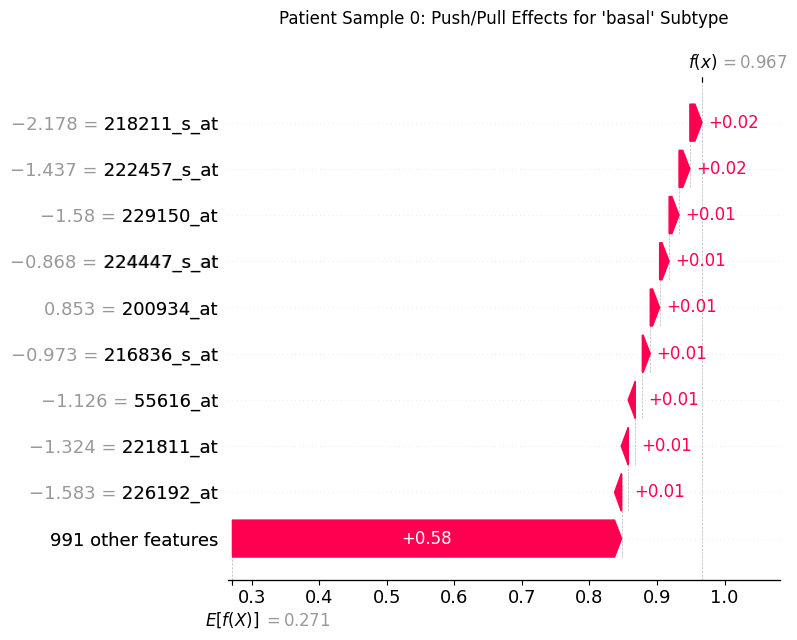

In [21]:
sample_idx = 0  # First patient sample

# Isolate the 1000 gene values for patient 0, class 'basal'
patient_basal_shap = shap_array[sample_idx, :, basal_class_idx]

# TreeExplainer expected values match the number of classes
base_value = explainer.expected_value[basal_class_idx]

plt.figure(figsize=(10, 6))
shap.waterfall_plot(
    shap.Explanation(
        values=patient_basal_shap,
        base_values=base_value,
        data=X_scaled[sample_idx],
        feature_names=selected_gene_names
    ),
    show=False
)
plt.title(f"Patient Sample {sample_idx}: Push/Pull Effects for 'basal' Subtype", fontsize=12, pad=20)
plt.tight_layout()
plt.show()